ML course homework 2: EDA

Для выполнения этой домашней работы я взял датасет на Kaggle о ~~кредитном скоринге~~ Банкоовской маркетинговой компании (оказалось, название не соответствует данным) с задачей предсказать, оформит ли клиент срочный депозит(https://www.kaggle.com/datasets/kapturovalexander/bank-credit-scoring?resource=download, Задание 1).

Задание 2
    
    А:

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

df = pd.read_csv("bank.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [176]:
df.tail()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [177]:
df.shape


(4521, 17)

In [178]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [179]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [180]:
df.describe(include="object")


C:\Users\USER\AppData\Local\Temp\ipykernel_21000\3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [181]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [182]:
df.duplicated().sum()


np.int64(0)

In [183]:
df["age"].min()


np.int64(19)

In [184]:
df["age"].max()


np.int64(87)

In [185]:
df.nunique()


age            67
job            12
marital         3
education       4
default         2
balance      2353
housing         2
loan            2
contact         3
day            31
month          12
duration      875
campaign       32
pdays         292
previous       24
poutcome        4
y               2
dtype: int64

In [186]:
(df["age"] < 0).sum()

np.int64(0)


    Б:

Как видно из df.isnull().sum(), в датасете отсутствуют пропуски. Если бы они были, можно было бы применить:

 - Удаление пропусков:

In [187]:
df.dropna()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


 - Заполнение модой. Лучше всего подошло бы для заполнения пропусков в "job", так как значения в "job" строчные - медиана/среднее неприменимы для категориальных признаков

In [188]:
df["job"].fillna(df["job"].mode()[0])


0          unemployed
1            services
2          management
3          management
4         blue-collar
            ...      
4516         services
4517    self-employed
4518       technician
4519      blue-collar
4520     entrepreneur
Name: job, Length: 4521, dtype: str

- Заполнение медианой. Хорошо подходит, когда немногочисленные очень большие/маленькие значения искажают среднее значение. Например, для этого датасета такие искажения могут быть в "balance" (очень богатые клиенты, или клиенты, находящиеся в крупных долгах):

In [189]:
df["balance"].fillna(df["balance"].median())


0       1787
1       4789
2       1350
3       1476
4          0
        ... 
4516    -333
4517   -3313
4518     295
4519    1137
4520    1136
Name: balance, Length: 4521, dtype: int64

 - Заполнение константой. Константа подходит, когда, например, пропуски могут значить отсутствие контакта, принадлежности к чему-либо. В данном датасете признак pdays - количество дней с последнего контакта, а значение -1 - отсутвие последнего контакта. Легко предположить, что при отсутствии контакта в pdays будет пропуск, соответсвтенно их мы и заполняем значениями -1

In [190]:
df["pdays"].fillna(-1)

0        -1
1       339
2       330
3        -1
4        -1
       ... 
4516     -1
4517     -1
4518     -1
4519    211
4520    249
Name: pdays, Length: 4521, dtype: int64

    С:

В этой части работы надо для числовых колонок вывести min,max,mean,median, mode, перцентили/квартинтили и изучить дисперсию/ассимметрию/эксцесс данных. Я не хотел высчитывать все вручную - отсортировал основной DataFrame до численных значений и уже его использовал для создания нового DataFrame, где бывшие колонки - строки, а новые колонки - характеристики.


In [191]:
numeric_cols = df.select_dtypes(include="number")

numeric_stats = pd.DataFrame({
    "min": numeric_cols.min(),
    "max": numeric_cols.max(),
    "mean": numeric_cols.mean(),
    "median": numeric_cols.median(),
    "mode": numeric_cols.mode().iloc[0],
    "5%": numeric_cols.quantile(0.05),
    "25%": numeric_cols.quantile(0.25),
    "50%": numeric_cols.quantile(0.50),
    "75%": numeric_cols.quantile(0.75),
    "95%": numeric_cols.quantile(0.95),
    "var": numeric_cols.var(),
    "skewness": numeric_cols.skew(),
    "kurtosis": numeric_cols.kurt(),
})

numeric_stats


,min,max,mean,median,mode,5%,25%,50%,75%,95%,var,skewness,kurtosis
age,19,87,41.170095,39.0,34,27.0,33.0,39.0,49.0,59.0,1.118562e+02,0.699501,0.348775
balance,-3313,71188,1422.657819,444.0,0,-162.0,69.0,444.0,1480.0,6102.0,9.057922e+06,6.596431,88.390332
day,1,31,15.915284,16.0,20,3.0,9.0,16.0,21.0,30.0,6.802402e+01,0.094627,-1.039531
duration,4,3025,263.961292,185.0,123,31.0,104.0,185.0,329.0,763.0,6.752547e+04,2.772420,12.530050
campaign,1,50,2.793630,2.0,1,1.0,1.0,2.0,3.0,8.0,9.670897e+00,4.743914,37.168920
pdays,-1,871,39.766645,-1.0,-1,-1.0,-1.0,-1.0,-1.0,317.0,1.002424e+04,2.717071,7.957128
previous,0,25,0.542579,0.0,0,0.0,0.0,0.0,0.0,3.0,2.868153e+00,5.875259,51.995212


Можно видеть следующее: 
    
1. Дисперсия большая у balance, pdays, duration - есть очень большие/маленькие значение, сильно выбивающиеся из тенденции; у age и day дисперсия меньше - распределение более стабильное.
2. Из всех колонок условно симметричной является только day. Остальные имеют положительную асимметрию - маленькие значения количественно доминируют над большими. Особенно выделяются balance, campaign и previous, где это различие гораздо больше
3. Самый большой эксцесс наблюдается в balance,campaign и previos - в них хвосты очень тяжелые. У day эксцесс отрицательный - более плоское распределение, без выбросов



    D:

В этой части задания работаю с энкодингом и Feature инжинирингом. Сначала сделал кодирование категорий с помощью pd.get_dummies:

In [192]:
pd.get_dummies(df, columns=[
    "job", "marital", "education", "default","housing", "loan", "contact", "month", "poutcome", "y"
])

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,y_no,y_yes
0,30,1787,19,79,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,True,True,False
1,33,4789,11,220,1,339,4,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,35,1350,16,185,1,330,1,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,30,1476,3,199,4,-1,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
4,59,0,5,226,1,-1,0,False,True,False,...,True,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,-333,30,329,5,-1,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
4517,57,-3313,9,153,1,-1,0,False,False,False,...,True,False,False,False,False,False,False,True,True,False
4518,57,295,19,151,11,-1,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
4519,28,1137,6,129,4,211,3,False,True,False,...,False,False,False,False,False,True,False,False,True,False


Label Encoding для моего датасета не подходит, так как между признаками не имеется определенного порядка. Target Encoding имеет смысл на отдельных колонках, например на job:

In [193]:
target_means = df.groupby("job")["y"].apply(lambda x: x.map({"yes": 1, "no": 0}).mean())

job_te = df["job"].map(target_means)

pd.DataFrame({
    "job_before": df["job"],
    "job_after_te": job_te
})


,job_before,job_after_te
0,unemployed,0.101562
1,services,0.091127
2,management,0.135191
3,management,0.135191
4,blue-collar,0.072939
...,...,...
4516,services,0.091127
4517,self-employed,0.109290
4518,technician,0.108073
4519,blue-collar,0.072939


Feature Hashing используется для признаков с большим числом уникальных значений. На этом датасете таких признаков нет, но в целом чтобы протестировать его работу достаточно захэшить и job:

In [194]:
from sklearn.feature_extraction import FeatureHasher

job_dicts = df["job"].apply(lambda x: {"job": x})


fh = FeatureHasher(n_features=8, input_type='dict')


hashed = fh.transform(job_dicts)

hashed_df = pd.DataFrame(hashed.toarray())

hashed_df

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
4516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
4517,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
4518,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4519,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Feature engeneering: добавил "was contacted before" - контактировали ли до этой маркетинговой кампании, и "duration bin" - разбитие звонков по категориям на короткие, средние, длинные и очень длинные

In [195]:
df["was_contacted_before"] = (df["previous"] > 0).astype(int)
df["duration_bin"] = pd.cut(df["duration"], bins=[0, 60, 180, 600, 2000],
                            labels=["short", "medium", "long", "very_long"])
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,was_contacted_before,duration_bin
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0,medium
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,1,long
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,1,long
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,0,long
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,0,long


    E: 
**Визуализация Данных**


 - Гистограммы/KDE:
 Визуализирую дистрибуцию балансов и возрастов

<Axes: xlabel='balance', ylabel='Count'>

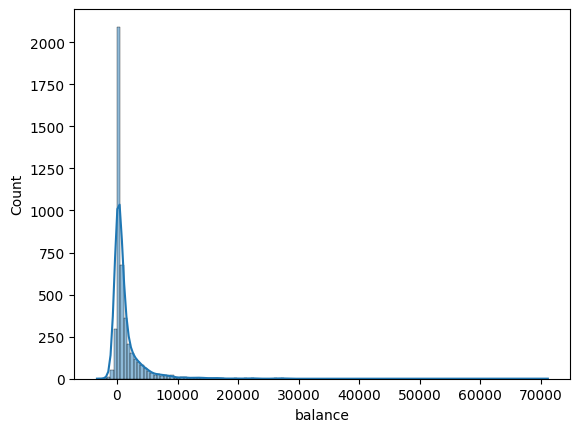

In [196]:
sns.histplot(df["balance"], kde=True)


<Axes: xlabel='age', ylabel='Count'>

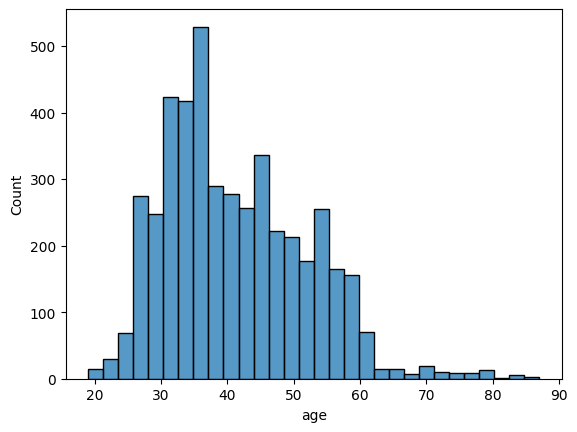

In [197]:
sns.histplot(df["age"], bins=30, kde=False)

- Scatter plot:

Тут я показал: 
- зависимость между балансом и длительностью разговора (обратная пропорциональность)
- конверсию в зависимости от возраста (старше=> больше)
- зависимость между кооличеством предыдущих контактов и duration (больше контактов - меньше duration)

In [198]:
px.scatter(df, x="duration", y="balance", color="y", hover_data=["job"])


<Axes: title={'center': 'Conversion Rate vs Age'}, xlabel='age', ylabel='Conversion Rate'>

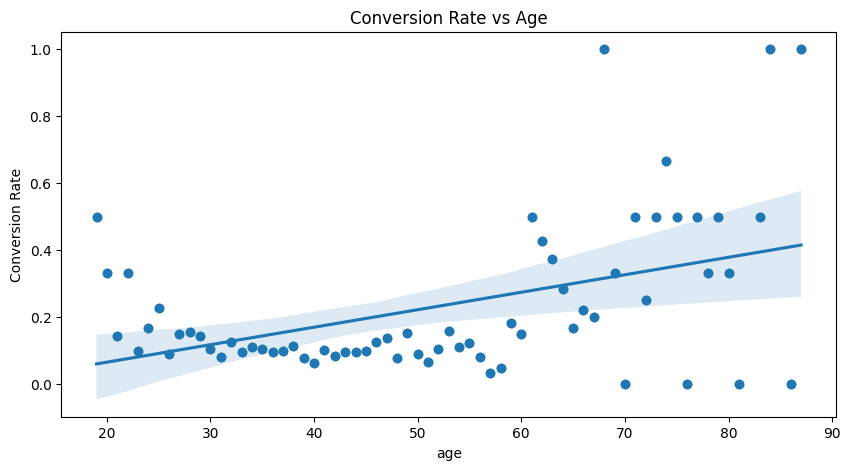

In [199]:
acceptance_by_age = df.assign(y_num = (df["y"] == "yes").astype(int)) \
                      .groupby("age")["y_num"].mean()
plt.figure(figsize=(10,5))
plt.scatter(acceptance_by_age.index, acceptance_by_age.values)
plt.xlabel("Age")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate vs Age")

sns.regplot(x=acceptance_by_age.index, y=acceptance_by_age.values, scatter=True)


<Axes: xlabel='duration', ylabel='campaign'>

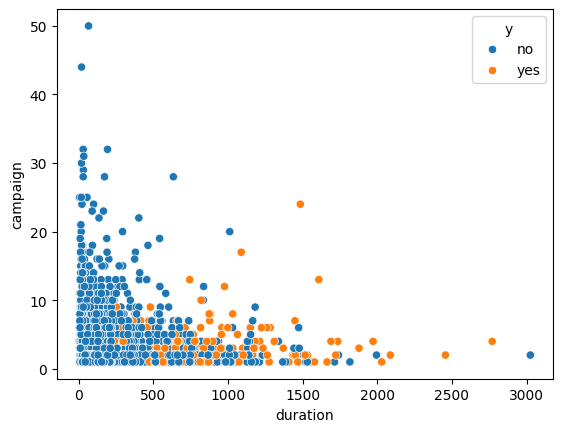

In [200]:
sns.scatterplot(x="duration", y="campaign", hue="y", data=df)


- Box plot:

Тут я показал: 
- дистрибуцию баланса
- дисперсию длины звонков (разделив на удачные и неудачные)

Text(0.5, 1.0, 'Balance Distribution ')

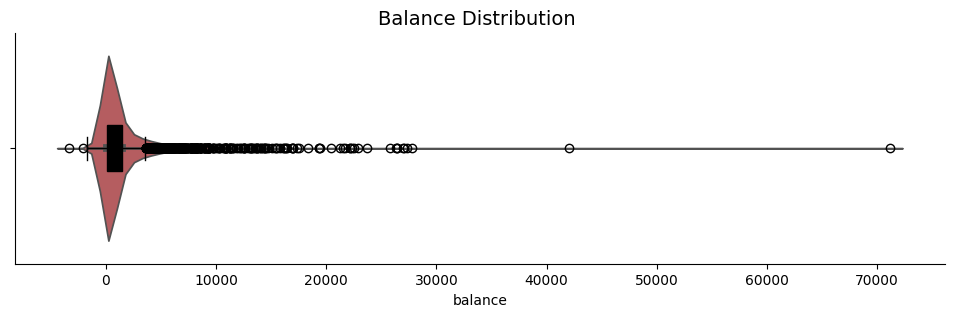

In [201]:
plt.figure(figsize=(12,3))
sns.violinplot(x=df["balance"], color="#C44E52")
sns.boxplot(x=df["balance"], width=0.2, color="black")
sns.despine()
plt.title("Balance Distribution ", fontsize=14)


Text(0.5, 1.0, 'Call Duration vs Subscription Result')

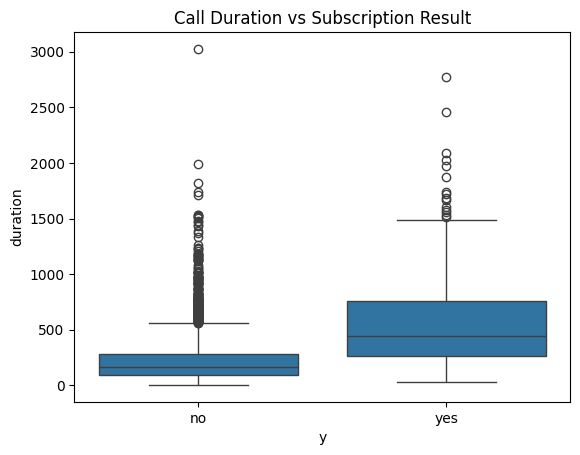

In [202]:
sns.boxplot(data=df, x="y", y="duration")
plt.title("Call Duration vs Subscription Result")



Text(0.5, 1.0, 'Age distribution')

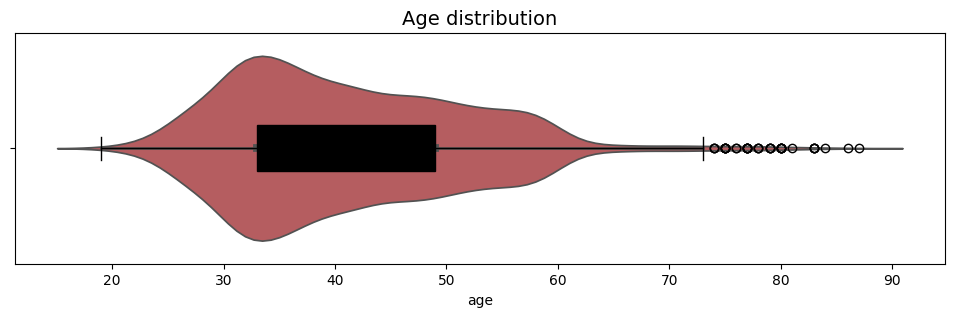

In [203]:
plt.figure(figsize=(12,3))
sns.violinplot(x=df["age"], color="#C44E52")
sns.boxplot(x=df["age"], width=0.2, color="black")
plt.title("Age distribution", fontsize = 14)



- Bar/count plot

здесь визуализирую категории,а именно:
 - количество подписок на депозит в зависимости от месяца
 - процент оформленных депозитов в зависимоти от работы (retired -больше всех, blue-collar - меньше)
 - процент  оформленных депозитов в зависимости от образования

Text(0.5, 1.0, 'Number of deposits per month')

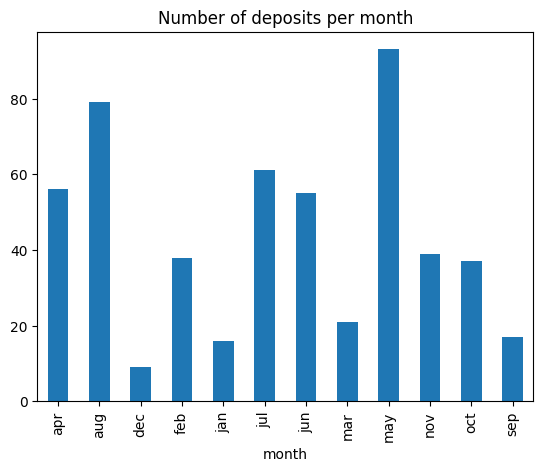

In [204]:
df[df["y"] == "yes"]["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of deposits per month")


Text(0.5, 1.0, 'Subscribtion Rate by Job')

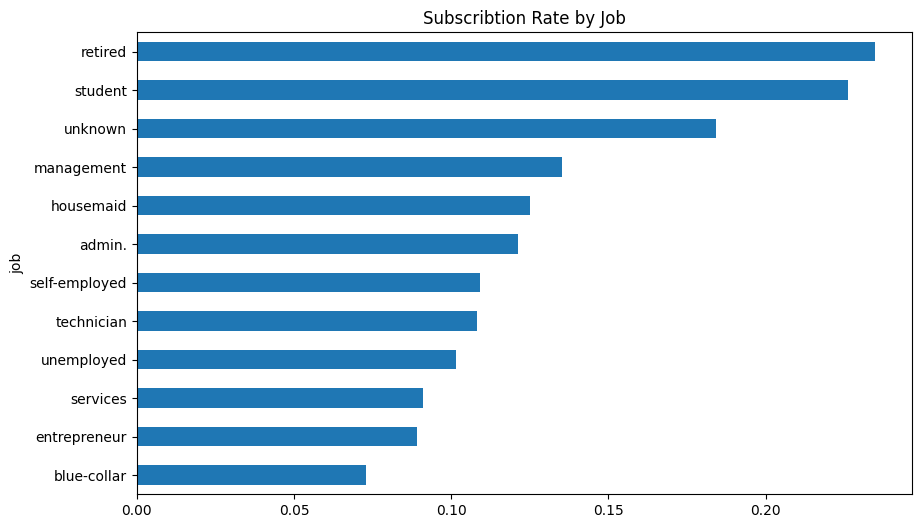

In [205]:
(df["y"] == "yes").groupby(df["job"]).mean().sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Subscribtion Rate by Job")


Text(0.5, 1.0, 'Subscribtion Rate by Education Level')

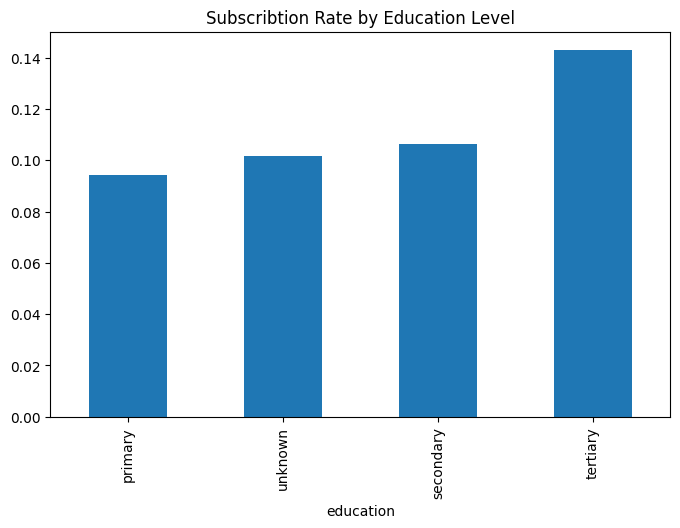

In [206]:
(df["y"] == "yes").groupby(df["education"]).mean().sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Subscribtion Rate by Education Level")


- Heatmap корреляций

Сделал хитмапы корреляций между:
 - нумерическими признаками
 - всеми признаками через one hot encoder
 - категориальными признаками и оформлением депозита
 - нумерическими признаками и оформлением депозита

<Axes: >

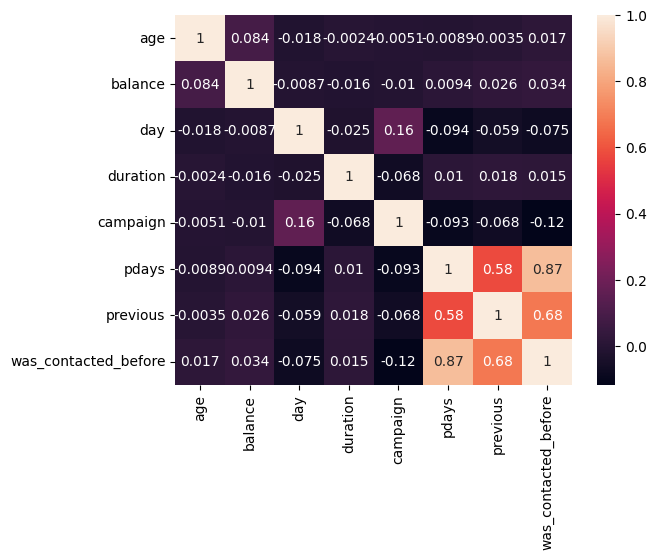

In [207]:
sns.heatmap(df.select_dtypes("number").corr(), annot=True)


<Axes: >

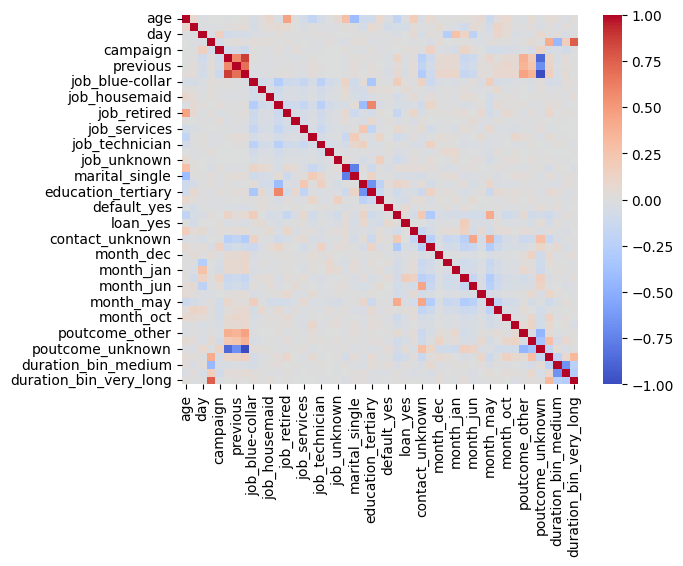

In [208]:
df_onehotencoder = pd.get_dummies(df, drop_first=True)
sns.heatmap(df_onehotencoder.corr(), cmap="coolwarm")


C:\Users\USER\AppData\Local\Temp\ipykernel_21000\1526669528.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = pd.get_dummies(df.select_dtypes("object"), drop_first=True)


Text(0.5, 1.0, 'Correlation of Categorical Features with Target')

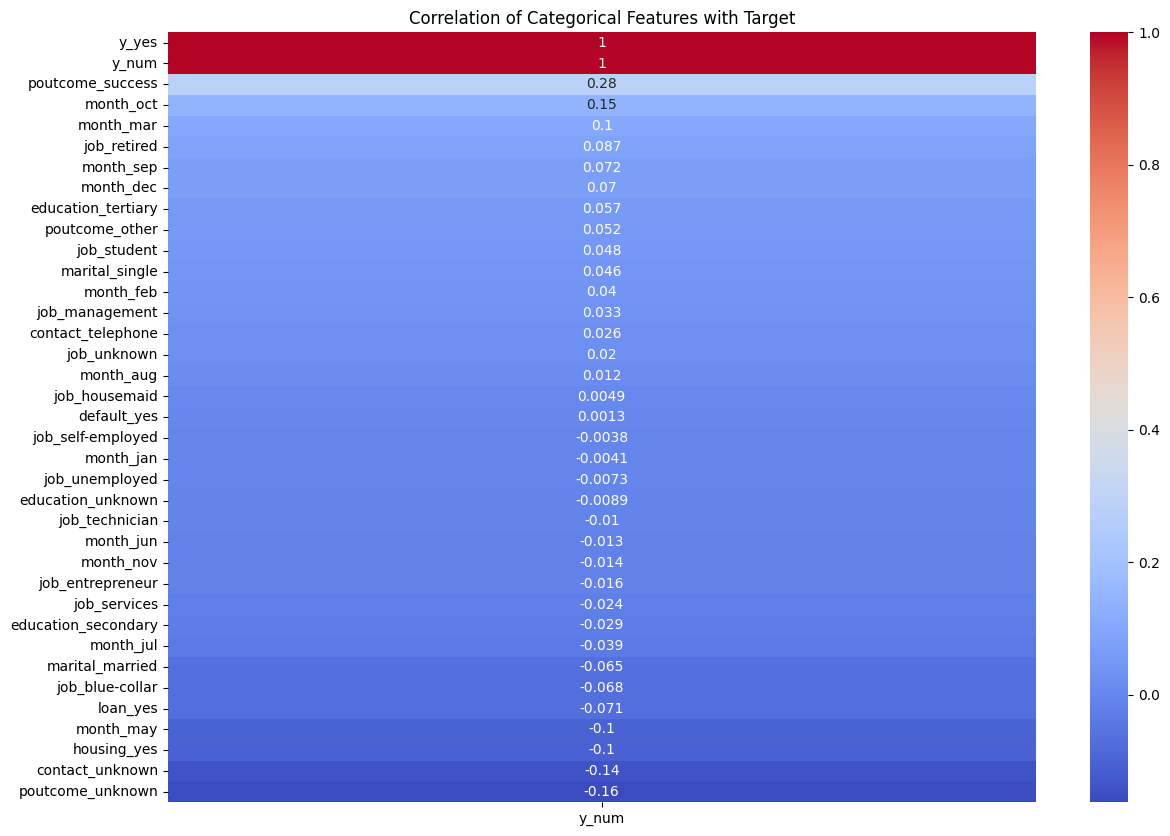

In [209]:
df_cat = pd.get_dummies(df.select_dtypes("object"), drop_first=True)
df_cat["y_num"] = (df["y"] == "yes").astype(int)

plt.figure(figsize=(14,10))
sns.heatmap(df_cat.corr()[["y_num"]].sort_values("y_num", ascending=False), 
            annot=True, cmap="coolwarm")
plt.title("Correlation of Categorical Features with Target")


Text(0.5, 1.0, 'Correlation of Numerical Features with Target')

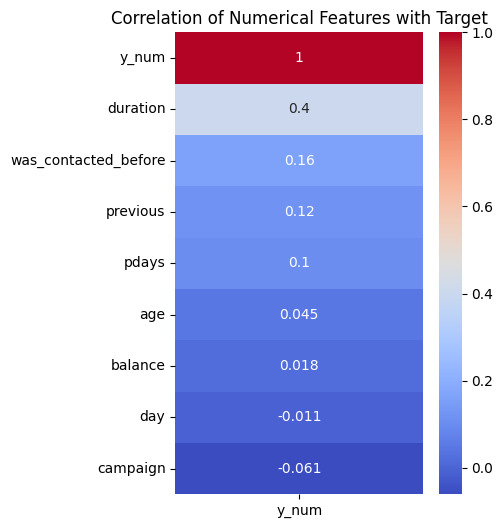

In [210]:
num_df = df.select_dtypes("number")
num_df["y_num"] = df_cat["y_num"]

plt.figure(figsize=(4,6))
sns.heatmap(num_df.corr()[["y_num"]].sort_values("y_num", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlation of Numerical Features with Target")




    F:
**Итоговые выводы**

Что я понял про датасет?
- С успехом в оформлении депозита больше всего коррелирует длительность звонка
- Баланс почти не влияет на успех контакта
- Тип работы влияет на конверсию (среди blue-collar она в 3 раза меньше, чем среди retired/student, и в 2 раза мменьше, чем среди менеджеров )
- Большое количество звонков за текущую кампанию(назойливость) снижает шанс успеха
- Наличие предыдущих контактов, в особенносни успешных, наоборот, улучшают конверсию (самая большая корреляция среди категориальных)
- Возраст и образование немного влияеют на исход (чем больше/выше, тем больше шанс на оформление депозита)
- Клиенты с кредитами оформляют депозит реже (Фин. нагрузка снижает интерес к депозитам)
- По моему мнению, датасет не очень подходит для глубокого анализа/построения линейной модели, так как корреляций между признаками и исходом очень мало, многие признаки не влияют на исход, а также не хватает других важных данных вроде дохода или кредитной истории


Гипотезы/наблюдения:
- Влияние возраста: конверсия среди более старшего населения выше, что связано с их финансовой стабильностью
- Чем длиннее звонок, тем больше шанс на положительный для компании исход (корреляция 0.4). Скорее это даже не причина, а следствие заинтересованности клиентаю
- Большой баланс НЕ коррелирует с интересом в срочном депозите. Думаю, связано это с тем, что люди с большим балансом больше заинтересованы в иных видах инвестиций.
- Если клиент участвовал в прошлых акциях, вероятность того, что он оформит депозит снова, выше (корреляция 0.28)
- Чем выше уровень образования у человека, тем больше шанс, что срочный депозит возьмут

Что бы я сделал дальше?:
- С помощью OneHorEncoder закодировал и привел бы все данные к числовому виду
- Для обучения выбрал бы Decision tree модель, т.к. она хороша для нахождения нелинейных зависимостей (так как в датасете, как раз, линейные зависимости слабые) и в целом ее логику легко наложить на этот датасет
- Модель я бы обучал предсказывать: оформит ли клиент срочный депозит (отталкиваясь от его вводных)

Какие подсказки брал у AI
- советы по улучшению визуализации (annot, cmap в heatmaps, признаки Violinplot)
- помощь с feature hashing (как работает и какие методы используются, как применять)
- дебажил код

что в итоге проверял/дописывал руками:
- упрощал код для визуализации (сокращал строки, убирал ненужные характеристики)

